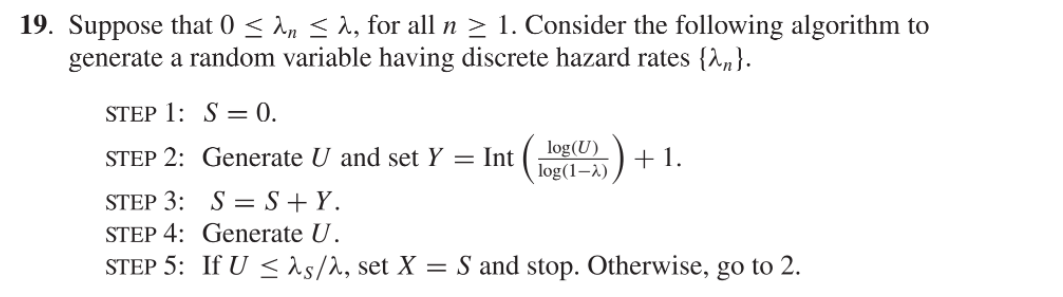

1. What is the distribution of $Y$ in Step 2?

$$
\begin{aligned}
P(Y=y) &= P(y = \left\lfloor \frac{\log(U)}{\log(1-\lambda)} \right\rfloor +1)\\
&=P(y -1  \le  \frac{\log(U)}{\log(1-\lambda)} < y) \\
&= P((y-1)\log(1-\lambda) \ge \log(U) > y \log(1-\lambda)) \\
&= P((1-\lambda)^{y-1} \ge U > (1-\lambda)^y) \\
&= (1-\lambda)^{y-1} - (1-\lambda)^y \\
&= \lambda(1-\lambda)^{y-1}
\end{aligned}
$$

$Y \sim Geo(\lambda)$

2. Explain what the algorithm is doing.

先以最大發生幾率 $\lambda$ 隨機生成 $Y$ 並前進。當進入位置 $S$ 時，以 $\lambda_S/\lambda$ 的幾率接受，如果被拒絕則繼續前進。因爲幾何分佈有無記憶性，因此從任意地方繼續出發與從原點出發的分佈一樣。

$$
P(Y>y)=(1-\lambda)^y,\quad P(Y>s+t|Y>s) = \frac{(1-\lambda)^{s+t}}{(1-\lambda)^s}=(1-\lambda)^t=P(Y>t)
$$

3. Argue that $X$ is a random variable with discrete hazard rates $\{\lambda_n \}$

給定 $X>n$ 等同于 $Y$ 從 $n-1$ 步出發，根據無記憶性仍服從 $Geo(\lambda)$ 而無須關注之前停留次數。

$$
P(X=n|X\ge n) = P(Y=1)P(U\le \lambda_n/\lambda) = \lambda \times \frac{\lambda_n}{\lambda} = \lambda_n
$$

10. The negative binomial probability mass function with parameters(r, p), where
r is a positive integer and 0 < p < 1, is given by

1. Use the relationship between negative binomial and geometric random variables and the results of Example 4d to obtain an algorithm for simulating from this distribution.

$X_1, \dots, X_r \overset{iid}{\sim} Geo(p)$

$$
\sum_{i=1}^r X_i \sim NegBin(r,p)
$$

In [13]:
import numpy as np


def neg_bin(r, p):
    u = np.random.uniform(0, 1, r)
    geo = np.ceil(np.log(u) / np.log(1 - p))
    return geo.sum()


neg_bin(2, 0.5)

np.float64(3.0)

2. Verify the relation
$$
p_{j+1}=\frac{j(1-p)}{j+1-r}p_j
$$

$j=n$

$$
\frac{n(1-p)}{j+1-r}p_n = \frac{n(1-p)}{n+1-r}\frac{(n-1)!}{(n-r)!(r-1)!}p^r(1-p)^{n-r}=\frac{n!}{(n+1-r)!(r-1)!}p^r(1-p)^{n+1-r}=p_{n+1}
$$

3. Use the relation in part (b) to give a second algorithm for generating negative binomial random variables.

In [ ]:
def neg_bin(r, p):
    u = np.random.uniform(0, 1)
    j = r
    p_j = p**r
    cum = p_j
    while u >= cum:
        j += 1
        p_j *= j * (1 - p) / (j + 1 - r)
        cum += p_j
    return j

3. Use the interpretation of the negative binomial distribution as the number of trials it takes to amass a total of r successes when each trial independently results in a success with probability p, to obtain still another approach for generating such a random variable.

In [ ]:
def neg_bin(r, p):
    succ, total = 0, 0
    while succ < r:
        if np.random.uniform() < p:
            succ += 1
        total += 1
    return total

12. If Z is a standard normal random variable, show that

$$
E[|Z|] = \left(\frac{2}{\pi} \right)^{1/2}\approx 0.798
$$

$$
E[|Z|] = 2\int_0^\infty \frac{z}{\sqrt{2\pi}}e^{-\frac{z^2}{2}} dz  = 2\int_0^1 \frac{1-u}{u^3\sqrt{2\pi}}e^{-\frac{(1-u)^2}{2u^2}} du,\quad u = \frac{1}{1+z}
$$

In [17]:
u = np.random.uniform(0, 1, 1_000_000)
np.mean(
    2 * (1 - u) / (u**3 * np.sqrt(2 * np.pi)) * np.exp(-((1 - u) ** 2) / (2 * u**2))
)

np.float64(0.7985795429357264)

14. Let X be a binomial random variable with parameters n and p. Suppose that we want to generate a random variable Y whose probability mass function is the same as the conditional mass function of X given that X ≥ k, for some k ≤ n. Let α = P{X ≥ k} and suppose that the value of α has been computed.
    1. Give the inverse transform method for generating Y . 

$$
P(Y = j) = P(X=j|X\ge k) = \frac{P(X=j)}{\alpha}=\frac{1}{\alpha}{n \choose j}p^j(1-p)^{n-j},\quad j=k,k+1,\dots,n
$$
Algorithm
1. Generate $U\sim$ Uniform(0,1)
2. Find $j=\min\set{\sum_{i=k}^j\frac{P(X=i)}{\alpha}\ge U | j=k,k+1,\dots,n}$
3. Set $Y=j$

2. Give a second method for generating Y .


1. Generate $X \sim \text{Binomial}(n, p)$
2. If $X \geq k$, set $Y=X$
3. Otherwise, reject and return to step 1

A random selection of m balls is to be made from an urn that contains n balls,
ni of which have color type i,
r
i=1
ni = n. Discuss efficient procedures for
simulating X1,..., Xr
, where Xi denotes the number of withdrawn balls that
have color type i.

For $i = 1, 2, \ldots, m$
1. Generate $U \sim \text{Uniform}(0, 1)$, and set $J=\lceil (n-i+1)U \rceil $
2. Swap ball $i$ and ball $J$

Take out the first m balls and count.